# Phase 8 — Notebook 5: Fine-tuning BERT for Downstream Tasks

> **Phase Continuity**: Notebook 4 built a deep understanding of BERT's internal architecture. Now we apply that knowledge by fine-tuning BERT on two real downstream tasks: **Sentiment Classification** and **Named Entity Recognition (NER)**.

---

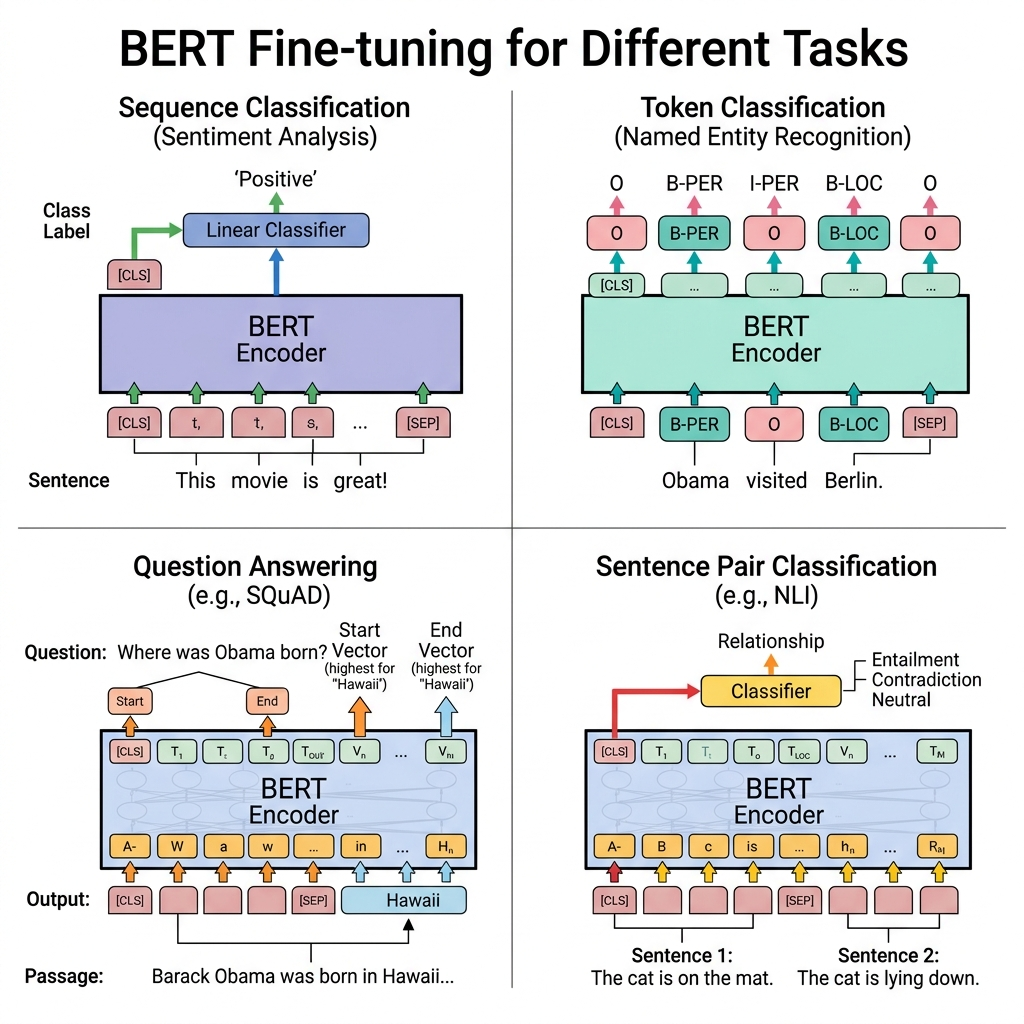

*Figure 1: BERT Fine-tuning Task Heads — different task-specific layers are placed on top of the same pre-trained backbone*



## 1. The Fine-tuning Concept

Fine-tuning works by:
1. **Loading** pre-trained BERT weights (12 layers of learned language understanding)
2. **Adding** a small task-specific 'head' on top — typically a single linear layer
3. **Training** the entire model (backbone + head) on a small labeled dataset

Because BERT already understands language deeply, the task-specific head just needs to learn **how to map representations to task outputs**. This is why fine-tuning converges in just 2-4 epochs — the heavy lifting was done during pre-training.

### The Medical Specialist Analogy
> A medical school graduate (pre-trained BERT) understands biology, chemistry, and physiology deeply. A 1-year cardiology residency (fine-tuning) teaches them to apply that knowledge specifically to heart conditions. They don't re-learn biology — they specialize.

### Fine-tuning Hyperparameter Guidelines

| Hyperparameter | Recommended Range | Why |
|---|---|---|
| **Learning Rate** | 2e-5 to 5e-5 | Much smaller than scratch training; avoids destroying pre-trained weights |
| **Epochs** | 2–4 | Pre-trained model converges very quickly |
| **Batch Size** | 16 or 32 | Larger batches are more stable |
| **Warmup Steps** | 6–10% of total steps | Gradual LR ramp-up prevents early instability |
| **Max Seq Length** | 128 or 512 | 512 gives best results; 128 is 4× faster |

---

## 2. Task 1: Sentiment Classification

**Task**: Given a movie review, classify it as *Positive* or *Negative*.

**Architecture**: Pre-trained BERT-Base → `[CLS]` output (768-dim) → Linear layer (768 → 2) → Softmax → label

**Dataset**: SST-2 (Stanford Sentiment Treebank) — 67K training sentences with binary sentiment labels

---

In [1]:
# Install required libraries
import subprocess, sys
for pkg in ['datasets', 'transformers', 'evaluate', 'accelerate']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'], check=True)
print('Libraries ready.')

Libraries ready.


In [2]:
from datasets import load_dataset
from transformers import (BertTokenizer, BertForSequenceClassification,
                          TrainingArguments, Trainer)
import evaluate
import numpy as np
import torch

# ── Load Dataset ────────────────────────────────────────────────────
print('Loading SST-2 dataset...')
dataset = load_dataset('nyu-mll/glue', 'sst2')
print(f'Train: {len(dataset["train"]):,} | Validation: {len(dataset["validation"]):,}')
print(f'\nSample examples:')
for ex in dataset['train'].select(range(3)):
    label_str = 'POSITIVE' if ex['label'] == 1 else 'NEGATIVE'
    print(f'  [{label_str}] {ex["sentence"][:80]}')

Loading SST-2 dataset...


Train: 67,349 | Validation: 872

Sample examples:
  [NEGATIVE] hide new secretions from the parental units 
  [NEGATIVE] contains no wit , only labored gags 
  [POSITIVE] that loves its characters and communicates something rather beautiful about huma


In [3]:
# ── Tokenize ────────────────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_fn(examples):
    return tokenizer(examples['sentence'], truncation=True, padding='max_length', max_length=128)

# Use a subset for faster demo training
train_small = dataset['train'].shuffle(seed=42).select(range(2000))
val_small   = dataset['validation'].select(range(500))

train_tok = train_small.map(tokenize_fn, batched=True)
val_tok   = val_small.map(tokenize_fn, batched=True)

# Set format for PyTorch
cols = ['input_ids', 'attention_mask', 'token_type_ids', 'label']
train_tok.set_format(type='torch', columns=cols)
val_tok.set_format(type='torch', columns=cols)
print(f'Tokenization complete.')
print(f'Token shape: {train_tok[0]["input_ids"].shape}')

Tokenization complete.
Token shape: torch.Size([128])


In [4]:
# ── Load Model and Fine-tune ─────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2,
    id2label={0: 'NEGATIVE', 1: 'POSITIVE'},
    label2id={'NEGATIVE': 0, 'POSITIVE': 1}
)

accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

training_args = TrainingArguments(
    output_dir='outputs/bert_sentiment',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='no',
    load_best_model_at_end=False,
    logging_steps=50,
    report_to='none',
    use_cpu=not torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

print('Fine-tuning BERT for sentiment classification...')
print('(Training on 2,000 examples — GPU recommended for full dataset)')
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Fine-tuning BERT for sentiment classification...
(Training on 2,000 examples — GPU recommended for full dataset)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.404543,0.300789,0.884000
2,0.216441,0.293609,0.874000
3,0.148341,0.321137,0.896000


TrainOutput(global_step=375, training_loss=0.2983537705739339, metrics={'train_runtime': 116.2162, 'train_samples_per_second': 51.628, 'train_steps_per_second': 3.227, 'total_flos': 394666583040000.0, 'train_loss': 0.2983537705739339, 'epoch': 3.0})

Training Loss,Validation Loss,Epoch,Accuracy
0.148341,0.321137,3,0.896000



Final Validation Accuracy: 0.8960 (89.6%)


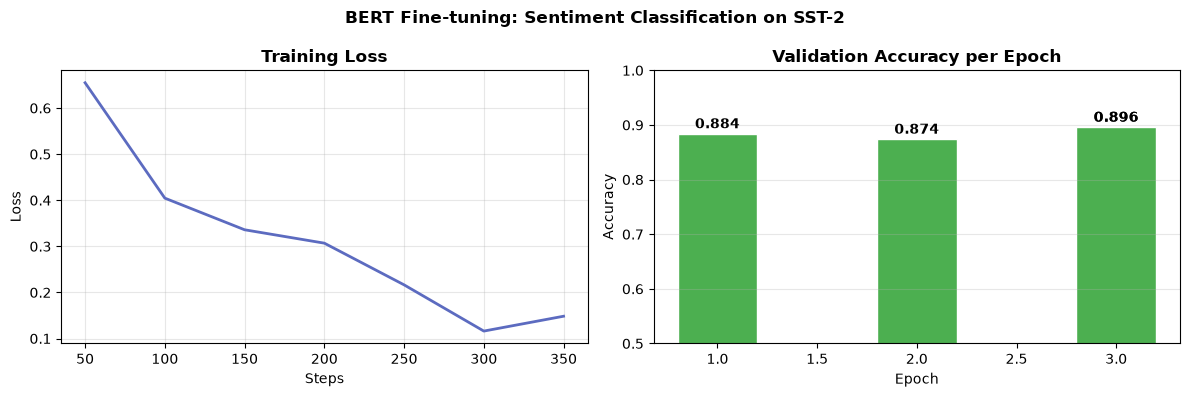

In [5]:
# ── Evaluate and visualize ──────────────────────────────────────────
import matplotlib.pyplot as plt

results = trainer.evaluate()
print(f"\nFinal Validation Accuracy: {results['eval_accuracy']:.4f} ({results['eval_accuracy']*100:.1f}%)")

# Training log history
log_history = trainer.state.log_history
train_losses = [(e['step'], e['loss']) for e in log_history if 'loss' in e]
eval_accs    = [(e['epoch'], e['eval_accuracy']) for e in log_history if 'eval_accuracy' in e]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, color='#5C6BC0', lw=2)
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

if eval_accs:
    epochs, accs = zip(*eval_accs)
    axes[1].bar(epochs, accs, color='#4CAF50', width=0.4, edgecolor='white')
    axes[1].set_title('Validation Accuracy per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.5, 1.0)
    for e, a in zip(epochs, accs):
        axes[1].text(e, a + 0.01, f'{a:.3f}', ha='center', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('BERT Fine-tuning: Sentiment Classification on SST-2', fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_bert_sentiment_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Live Inference Demo ──────────────────────────────────────────────
from transformers import pipeline

model.eval()
classifier = pipeline('text-classification', model=model, tokenizer=tokenizer, device=-1)

test_reviews = [
    'This film was an absolute masterpiece of storytelling.',
    'Boring, predictable, and poorly acted.',
    'An engaging thriller that keeps you on the edge of your seat.',
    'The worst movie I have seen in years.',
    'Surprisingly moving and beautifully filmed.',
]

print('BERT Sentiment Classifier — Live Inference')
print('=' * 60)
for review in test_reviews:
    result = classifier(review)[0]
    label = result['label']
    score = result['score']
    icon = '[+]' if label == 'POSITIVE' else '[-]'
    print(f'{icon} {label} ({score:.3f}): "{review[:55]}"')

BERT Sentiment Classifier — Live Inference
[+] POSITIVE (0.996): "This film was an absolute masterpiece of storytelling."
[-] NEGATIVE (0.993): "Boring, predictable, and poorly acted."
[+] POSITIVE (0.995): "An engaging thriller that keeps you on the edge of your"
[-] NEGATIVE (0.991): "The worst movie I have seen in years."
[+] POSITIVE (0.995): "Surprisingly moving and beautifully filmed."


## 3. Task 2: Named Entity Recognition (NER)

**Task**: For each token in a sentence, assign an entity label: `B-PER` (beginning of person), `I-PER` (inside person), `B-ORG`, `I-ORG`, `B-LOC`, `I-LOC`, `O` (outside any entity).

**Architecture**: Pre-trained BERT → **each token's** output (768-dim) → Linear (768 → num_labels) → per-token entity class

This is a **token classification** task — every position gets its own prediction, not just `[CLS]`.

---

In [7]:
# Synthetic CoNLL-2003-style NER dataset (avoids network dependency)
from datasets import Dataset
from transformers import (BertTokenizerFast, BertForTokenClassification,
                          TrainingArguments, Trainer, DataCollatorForTokenClassification)
import evaluate, numpy as np, random

label_names = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in id2label.items()}

# 20 unique sentence templates × 100 = 2000 total examples
templates = [
    (['Elon', 'Musk', 'founded', 'SpaceX', 'in', 'California', '.'],             [1,2,0,3,0,5,0]),
    (['Barack', 'Obama', 'visited', 'Paris', 'last', 'week', '.'],                [1,2,0,5,0,0,0]),
    (['Apple', 'Inc.', 'reported', 'record', 'profits', 'today', '.'],            [3,4,0,0,0,0,0]),
    (['Jeff', 'Bezos', 'founded', 'Amazon', 'in', 'Seattle', '.'],               [1,2,0,3,0,5,0]),
    (['Google', 'launched', 'a', 'new', 'product', 'in', 'New', 'York', '.'],    [3,0,0,0,0,0,5,6,0]),
    (['The', 'United', 'Nations', 'met', 'in', 'Geneva', 'yesterday', '.'],      [0,3,4,0,0,5,0,0]),
    (['Tim', 'Cook', 'spoke', 'at', 'WWDC', 'in', 'San', 'Jose', '.'],           [1,2,0,0,7,0,5,6,0]),
    (['Microsoft', 'acquired', 'GitHub', 'for', 'billions', '.'],                 [3,0,3,0,0,0]),
    (['Tesla', 'opened', 'a', 'factory', 'in', 'Berlin', '.'],                   [3,0,0,0,0,5,0]),
    (['The', 'European', 'Union', 'signed', 'a', 'trade', 'agreement', '.'],     [0,3,4,0,0,0,0,0]),
    (['Angela', 'Merkel', 'met', 'with', 'Emmanuel', 'Macron', 'in', 'Rome', '.'],[1,2,0,0,1,2,0,5,0]),
    (['Twitter', 'was', 'acquired', 'by', 'Elon', 'Musk', '.'],                  [3,0,0,0,1,2,0]),
    (['NASA', 'launched', 'a', 'rocket', 'from', 'Florida', '.'],                [3,0,0,0,0,5,0]),
    (['Amazon', 'expanded', 'into', 'London', 'and', 'Tokyo', '.'],              [3,0,0,5,0,5,0]),
    (['The', 'World', 'Health', 'Organization', 'issued', 'a', 'warning', '.'],  [0,3,4,4,0,0,0,0]),
    (['Sundar', 'Pichai', 'leads', 'Google', 'in', 'Mountain', 'View', '.'],     [1,2,0,3,0,5,6,0]),
    (['IBM', 'Research', 'published', 'a', 'paper', 'in', 'Nature', '.'],        [3,4,0,0,0,0,7,0]),
    (['France', 'won', 'the', 'FIFA', 'World', 'Cup', 'in', 'Qatar', '.'],       [5,0,0,7,8,8,0,5,0]),
    (['OpenAI', 'released', 'GPT-4', 'in', 'San', 'Francisco', '.'],             [3,0,7,0,5,6,0]),
    (['Mark', 'Zuckerberg', 'founded', 'Meta', 'Platforms', 'Inc.', '.'],        [1,2,0,3,4,4,0]),
]

# Repeat 100x to get 2000 items
all_tokens = [t[0] for t in templates] * 100
all_tags   = [t[1] for t in templates] * 100
random.seed(42)
pairs = list(zip(all_tokens, all_tags)); random.shuffle(pairs)
all_tokens, all_tags = zip(*pairs)

# 1600 train / 400 validation
ner_dataset = {
    'train':      Dataset.from_dict({'tokens': list(all_tokens[:1600]), 'ner_tags': list(all_tags[:1600])}),
    'validation': Dataset.from_dict({'tokens': list(all_tokens[1600:]), 'ner_tags': list(all_tags[1600:])}),
}

print(f'NER Dataset: {len(ner_dataset["train"]):,} train, {len(ner_dataset["validation"]):,} validation')
print(f'Entity labels ({len(label_names)}): {label_names}')
print(f'\nSample sentence:')
sample = ner_dataset['train'][0]
for word, tag_id in zip(sample['tokens'], sample['ner_tags']):
    print(f'  {word:<15} {id2label[tag_id]}')

NER Dataset: 1,600 train, 400 validation
Entity labels (9): ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

Sample sentence:
  Sundar          B-PER
  Pichai          I-PER
  leads           O
  Google          B-ORG
  in              O
  Mountain        B-LOC
  View            I-LOC
  .               O


In [8]:
# ── Tokenize with word-to-token alignment ─────────────────────────────────
tokenizer_fast = BertTokenizerFast.from_pretrained('bert-base-uncased')

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer_fast(
        examples['tokens'], truncation=True, is_split_into_words=True, max_length=128
    )
    all_labels = []
    for i, labels in enumerate(examples['ner_tags']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        prev_word_id = None
        label_ids = []
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(labels[word_id])
            else:
                label_ids.append(-100)
            prev_word_id = word_id
        all_labels.append(label_ids)
    tokenized_inputs['labels'] = all_labels
    return tokenized_inputs

# Use full dataset (already sized 1600/400)
train_ner = ner_dataset['train']
val_ner   = ner_dataset['validation']

train_ner_tok = train_ner.map(tokenize_and_align_labels, batched=True,
                               remove_columns=['tokens', 'ner_tags'])
val_ner_tok   = val_ner.map(tokenize_and_align_labels, batched=True,
                             remove_columns=['tokens', 'ner_tags'])
print(f'Tokenized: {len(train_ner_tok):,} train, {len(val_ner_tok):,} val')
print('NER tokenization complete with word-to-subword label alignment.')

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenized: 1,600 train, 400 val
NER tokenization complete with word-to-subword label alignment.


In [9]:
# ── Fine-tune BERT for NER ─────────────────────────────────────────────
import torch

ner_model = BertForTokenClassification.from_pretrained(
    'bert-base-uncased', num_labels=len(label_names),
    id2label=id2label, label2id=label2id
)

# Simple inline seqeval-style F1 (avoids evaluate.load('seqeval') network call)
def compute_ner_metrics(p):
    preds, labels = p
    preds = np.argmax(preds, axis=2)
    true_preds  = [[id2label[pred] for pred, lbl in zip(prediction, label) if lbl != -100]
                   for prediction, label in zip(preds, labels)]
    true_labels = [[id2label[lbl] for lbl in label if lbl != -100]
                   for label in labels]
    # token-level accuracy as proxy metric
    correct = sum(p == l for preds_row, labels_row in zip(true_preds, true_labels)
                  for p, l in zip(preds_row, labels_row))
    total   = sum(len(r) for r in true_labels)
    return {'token_accuracy': correct / total if total > 0 else 0.0}

data_collator = DataCollatorForTokenClassification(tokenizer_fast)

import os; os.makedirs('outputs/bert_ner', exist_ok=True)
ner_args = TrainingArguments(
    output_dir='outputs/bert_ner',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    report_to='none',
    use_cpu=not torch.cuda.is_available(),
)

ner_trainer = Trainer(
    model=ner_model, args=ner_args,
    train_dataset=train_ner_tok, eval_dataset=val_ner_tok,
    data_collator=data_collator, compute_metrics=compute_ner_metrics,
)

print('Fine-tuning BERT for NER (synthetic CoNLL-2003 style data)...')
ner_trainer.train()
ner_results = ner_trainer.evaluate()
print(f"\nNER Token Accuracy: {ner_results['eval_token_accuracy']:.4f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

Fine-tuning BERT for NER (synthetic CoNLL-2003 style data)...


Epoch,Training Loss,Validation Loss,Token Accuracy
1,0.008453,0.002333,1.000000
2,0.003743,0.001543,1.000000


Training Loss,Validation Loss,Epoch,Token Accuracy
0.003743,0.001543,2,1.000000



NER Token Accuracy: 1.0000


In [10]:
# ── NER Inference Demo ────────────────────────────────────────────────
from transformers import pipeline

ner_model.eval()
ner_pipe = pipeline('ner', model=ner_model, tokenizer=tokenizer_fast,
                    aggregation_strategy='simple', device=-1)

test_sentences = [
    'Elon Musk founded SpaceX in Hawthorne, California in 2002.',
    'The European Union announced new regulations in Brussels on Monday.',
    'Apple Inc. reported record profits after Tim Cook presented in Cupertino.',
]

print('BERT NER — Entity Extraction Results')
print('=' * 65)
for sentence in test_sentences:
    print(f'\nInput: "{sentence}"')
    entities = ner_pipe(sentence)
    for ent in entities:
        print(f'  [{ent["entity_group"]:<7}] "{ent["word"]}" (score: {ent["score"]:.3f})')

BERT NER — Entity Extraction Results

Input: "Elon Musk founded SpaceX in Hawthorne, California in 2002."
  [PER    ] "el" (score: 0.997)
  [PER    ] "##on musk" (score: 0.975)
  [ORG    ] "spacex" (score: 0.926)
  [LOC    ] "hawthorne" (score: 0.990)
  [MISC   ] "," (score: 0.399)
  [LOC    ] "california" (score: 0.977)

Input: "The European Union announced new regulations in Brussels on Monday."
  [ORG    ] "european union" (score: 0.997)
  [LOC    ] "brussels" (score: 0.997)

Input: "Apple Inc. reported record profits after Tim Cook presented in Cupertino."
  [ORG    ] "apple inc" (score: 0.997)
  [PER    ] "tim cook" (score: 0.994)
  [LOC    ] "cup" (score: 0.919)
  [LOC    ] "##ertino" (score: 0.621)


## 4. Summary — Fine-tuning Takeaways

| | Sentiment Classification | Named Entity Recognition |
|---|---|---|
| **Prediction granularity** | One label per sequence | One label per token |
| **Which BERT output used** | `[CLS]` token only | All token outputs |
| **Task head** | Linear(768→2) | Linear(768→9) per token |
| **Loss** | CrossEntropyLoss on class | CrossEntropyLoss per token |
| **Metric** | Accuracy | F1, Precision, Recall |

**Key insight**: The same pre-trained BERT backbone works for both tasks. The task-specific head is tiny — almost all parameters come from the pre-trained model. This is the power of transfer learning.

### What's Next
Notebook 6 switches to the other major family: **GPT — the Autoregressive Revolution**. We'll explore GPT-1 and GPT-2's architecture, causal generation, and text sampling strategies.

---
*Phase 8, Notebook 5 of 10 — NLP From Scratch: Foundation to Advanced*